## 1. Import required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 2. Set the CSV filename
Set the path to your llama-benchy CSV file here.

In [2]:
csv_path = 'demo.csv'  # Change this to your CSV file name

## 3. Load and process the data
This cell loads the CSV and extracts phase, parameter, and concurrency information from the `test_name` column.

In [3]:
# Check file exists
if not Path(csv_path).exists():
    raise FileNotFoundError(f'CSV file not found: {csv_path}')

df = pd.read_csv(csv_path)
if 'test_name' not in df.columns:
    raise ValueError('Missing required column: test_name')

import re
pattern = r'(pp|tg)\s*(\d+)\s*\(\s*c(\d+)\s*\)'
extracted = df['test_name'].str.extract(pattern)
df['phase'] = extracted[0]
df['param'] = pd.to_numeric(extracted[1], errors='coerce')
df['concurrency'] = pd.to_numeric(extracted[2], errors='coerce')
df = df.dropna(subset=['phase', 'concurrency']).copy()
df.head()

,model,test_name,t_s_mean,t_s_std,t_s_req_mean,t_s_req_std,peak_ts_mean,peak_ts_std,peak_ts_req_mean,peak_ts_req_std,ttfr_mean,ttfr_std,est_ppt_mean,est_ppt_std,e2e_ttft_mean,e2e_ttft_std,phase,param,concurrency
0,Qwen/Qwen3.6-27B,pp128 (c1),117.996702,3.370324,117.996702,3.370324,NaN,NaN,NaN,NaN,1093.828325,34.472642,1091.410598,34.472642,1093.828325,34.472642,pp,128,1
1,Qwen/Qwen3.6-27B,tg128 (c1),15.345280,0.265205,15.345280,0.265205,18.000000,2.828427,18.000000,2.828427,NaN,NaN,NaN,NaN,NaN,NaN,tg,128,1
2,Qwen/Qwen3.6-27B,pp128 (c2),124.111437,10.503190,62.159171,5.269383,NaN,NaN,NaN,NaN,2089.281133,168.576245,2086.863406,168.576245,2089.281133,168.576245,pp,128,2
3,Qwen/Qwen3.6-27B,tg128 (c2),25.358746,0.699182,12.719587,0.302386,27.333333,1.885618,13.833333,1.462494,NaN,NaN,NaN,NaN,NaN,NaN,tg,128,2
4,Qwen/Qwen3.6-27B,pp128 (c4),126.653413,6.476828,31.700706,1.629999,NaN,NaN,NaN,NaN,4084.579437,198.991723,4082.161710,198.991723,4084.579437,198.991723,pp,128,4


## 4. Set up plot style
This cell configures the appearance of the plots.

In [4]:
COLORS = {
    'pp': '#2E86AB',
    'tg': '#A23B72',
    'pp_tsr': '#7FB3D5',
    'tg_tsr': '#D98880',
    'pp_light': '#A7C7E7',
    'tg_light': '#E7B8D6'
}

PLOT_STYLE = {
    'figure.figsize': [14, 10],
    'axes.linewidth': 1.2,
    'font_scale': 1.1
}

sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=PLOT_STYLE['font_scale'])
rcparams = {k: v for k, v in PLOT_STYLE.items() if k != 'font_scale'}
plt.rcParams.update(rcparams)

## 5. Plot average throughput and request throughput
This cell shows the average throughput and request throughput for each phase and concurrency.

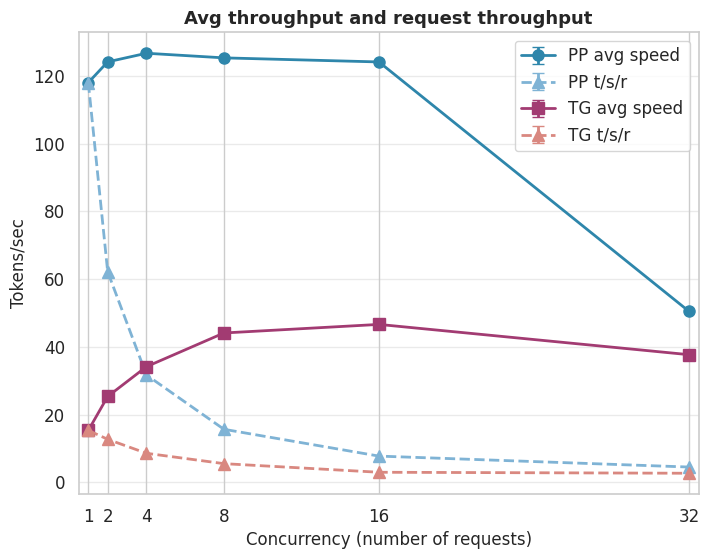

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
unique_concurrency = sorted(df['concurrency'].dropna().unique())
phase_offsets = {'pp': -0.08, 'tg': 0.08} if len(unique_concurrency) <= 1 else {'pp': 0.0, 'tg': 0.0}
for phase, marker, color in [('pp', 'o', COLORS['pp']), ('tg', 's', COLORS['tg'])]:
    subset = df[(df['phase'] == phase) & (df['t_s_mean'].notna())]
    if not subset.empty:
        agg = subset.groupby('concurrency')['t_s_mean'].agg(['mean', 'std']).reset_index()
        x = agg['concurrency'] + phase_offsets[phase]
        ax.errorbar(x, agg['mean'], yerr=agg['std'],
                   marker=marker, label=f'{phase.upper()} avg speed',
                   color=color, capsize=4, linewidth=2, markersize=8)
    subset_req = df[(df['phase'] == phase) & (df['t_s_req_mean'].notna())]
    if not subset_req.empty:
        agg_req = subset_req.groupby('concurrency')['t_s_req_mean'].agg(['mean', 'std']).reset_index()
        x_req = agg_req['concurrency'] + phase_offsets[phase]
        ax.errorbar(x_req, agg_req['mean'], yerr=agg_req['std'],
                   marker='^', label=f'{phase.upper()} t/s/r',
                   color=COLORS[f'{phase}_tsr'], linestyle='--', capsize=4, linewidth=2, markersize=8)
ax.set_xlabel('Concurrency (number of requests)', fontsize=12)
ax.set_ylabel('Tokens/sec', fontsize=12)
ax.set_title('Avg throughput and request throughput', fontsize=13, fontweight='bold')
if unique_concurrency:
    ax.set_xticks(unique_concurrency)
    if len(unique_concurrency) == 1:
        x = unique_concurrency[0]
        ax.set_xlim(x - 0.5, x + 0.5)
    else:
        ax.set_xlim(min(unique_concurrency) - 0.5, max(unique_concurrency) + 0.5)
ax.legend(frameon=True, fancybox=True)
ax.grid(axis='y', alpha=0.4)
plt.show()

## 6. Plot start latency (TTFR) for prefill phase
This cell shows the start latency (Time To First Response) for the prefill phase.

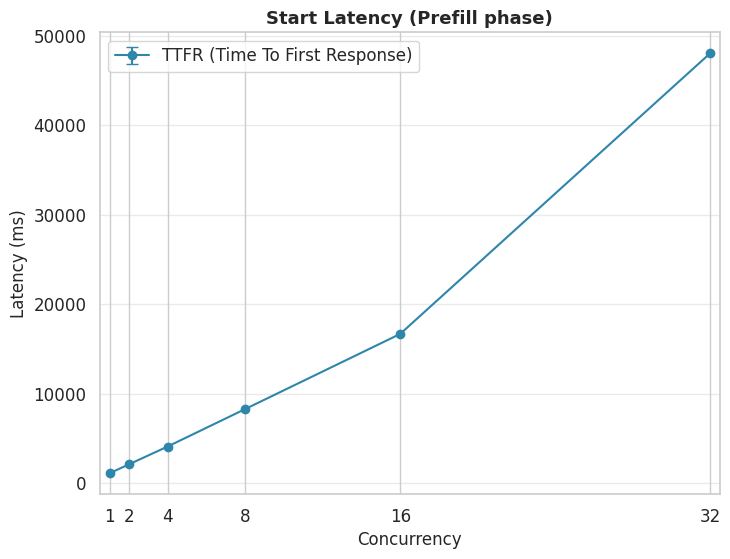

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
df_pp = df[df['phase'] == 'pp']
if df_pp['ttfr_mean'].notna().any():
    agg_ttfr = df_pp.dropna(subset=['ttfr_mean']).groupby('concurrency')['ttfr_mean'].agg(['mean', 'std']).reset_index()
    ax.errorbar(agg_ttfr['concurrency'], agg_ttfr['mean'], yerr=agg_ttfr['std'],
               marker='o', label='TTFR (Time To First Response)', color=COLORS['pp'], capsize=4)
ax.set_xlabel('Concurrency', fontsize=12)
ax.set_ylabel('Latency (ms)', fontsize=12)
ax.set_title('Start Latency (Prefill phase)', fontsize=13, fontweight='bold')
unique_concurrency = sorted(df_pp['concurrency'].dropna().unique())
if unique_concurrency:
    ax.set_xticks(unique_concurrency)
    if len(unique_concurrency) == 1:
        x = unique_concurrency[0]
        ax.set_xlim(x - 0.5, x + 0.5)
    else:
        ax.set_xlim(min(unique_concurrency) - 0.5, max(unique_concurrency) + 0.5)
ax.legend(frameon=True, fancybox=True)
ax.grid(axis='y', alpha=0.4)
plt.show()

## 7. Plot throughput heatmap
This cell shows a heatmap of average throughput (tokens/sec) for each phase and concurrency.

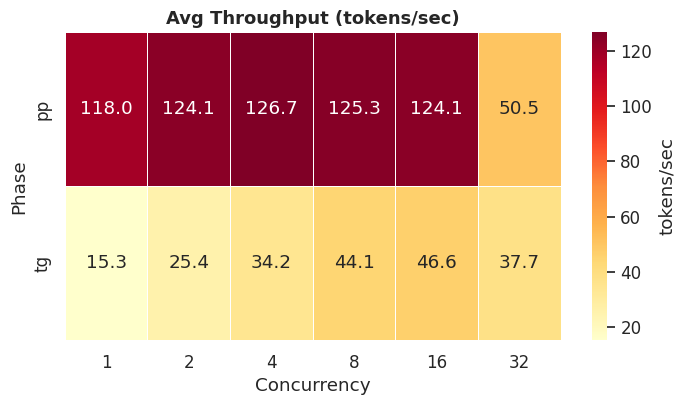

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
pivot_throughput = df.dropna(subset=['t_s_mean']).pivot_table(
    values='t_s_mean', index='phase', columns='concurrency', aggfunc='mean'
)
if not pivot_throughput.empty:
    sns.heatmap(pivot_throughput, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
               cbar_kws={'label': 'tokens/sec'}, linewidths=0.5)
    ax.set_title('Avg Throughput (tokens/sec)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Concurrency')
    ax.set_ylabel('Phase')
plt.show()

## 8. Show summary table
This cell displays a summary table of the main metrics for each phase and concurrency.

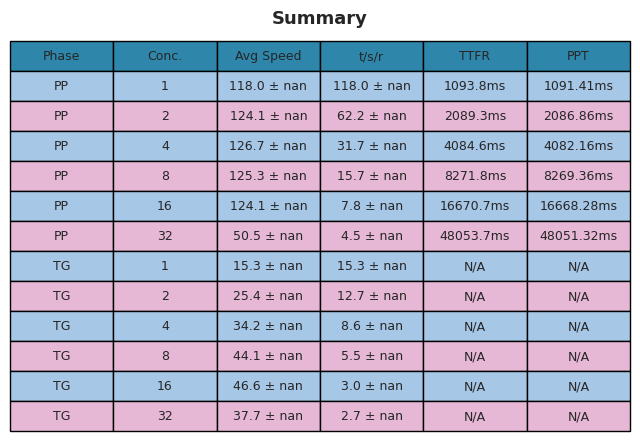

In [13]:
import numpy as np
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')
summary_rows = []
for phase in ['pp', 'tg']:
    for conc in sorted(df['concurrency'].unique()):
        subset = df[(df['phase'] == phase) & (df['concurrency'] == conc)]
        if not subset.empty and subset['t_s_mean'].notna().any():
            row = {
                'Phase': phase.upper(),
                'Conc.': conc,
                'Avg Speed': (f"{subset['t_s_mean'].mean():.1f} ± {subset['t_s_mean'].std():.1f}"
                            if subset['t_s_mean'].notna().any() else 'N/A'),
                't/s/r': (f"{subset['t_s_req_mean'].mean():.1f} ± {subset['t_s_req_mean'].std():.1f}"
                        if subset['t_s_req_mean'].notna().any() else 'N/A'),
                'TTFR': (f"{subset['ttfr_mean'].mean():.1f}ms"
                       if subset['ttfr_mean'].notna().any() else "N/A"),
                'PPT': (f"{subset['est_ppt_mean'].mean():.2f}ms"
                      if subset['est_ppt_mean'].notna().any() else "N/A")
            }
            summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    table = ax.table(cellText=summary_df.values, colLabels=summary_df.columns,
                    cellLoc='center', loc='center', colColours=[COLORS['pp']]*len(summary_df.columns))
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.8)
    for i in range(len(summary_df)):
        color = COLORS['pp_light'] if i % 2 == 0 else COLORS['tg_light']
        for j in range(len(summary_df.columns)):
            table[(i+1, j)].set_facecolor(color)
    ax.set_title('Summary', fontsize=13, fontweight='bold', pad=70)
plt.show()